# MAIN:

### A basic example of climate data:

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import matplotlib.ticker as mticker

from matplotlib.colors import TwoSlopeNorm

In [37]:
# Load dataset
mode="tavg"
df = pd.read_parquet(f"data/{mode}_anomaly.parquet")

month = "202508"
values = df.loc[month].values

# Load coordinates
coords_url = "https://www.ncei.noaa.gov/monitoring-content/cag/metadata/global-grid-coords.json"
coords = requests.get(coords_url).json()
lats = np.array(coords[mode]["latitudes"])
lons = np.array(coords[mode]["longitudes"])
grid = values.reshape(len(lats), len(lons))

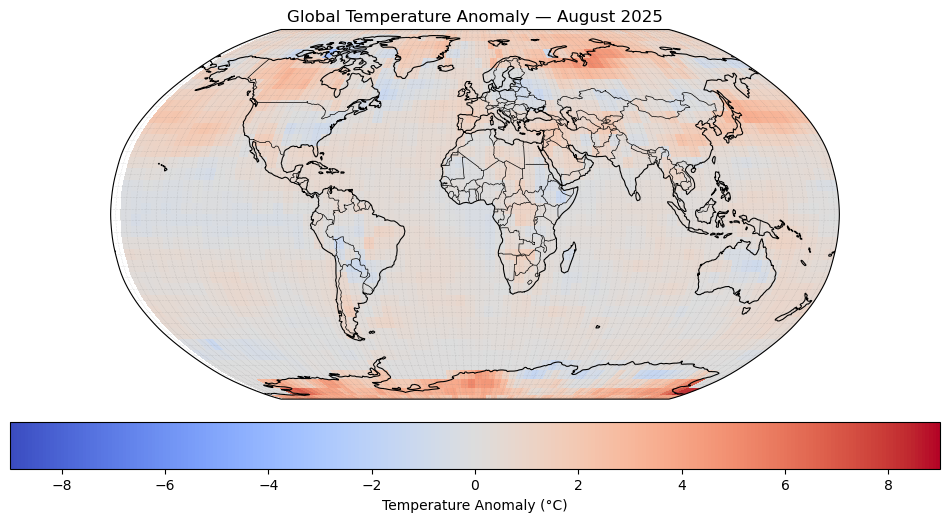

In [36]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

vmax = np.ceil(np.nanmax(np.abs(grid)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Dense gridlines based on your data grid
gl = ax.gridlines(
    draw_labels=False,  
    linewidth=0.4,
    color="gray",
    alpha=0.4,
    linestyle=":"
)

# Set grid spacing to match your original lat/lon arrays
gl.xlocator = mticker.FixedLocator(lons_shifted)
gl.ylocator = mticker.FixedLocator(lats)

lons_shifted = np.where(lons > 180, lons - 360, lons)
lon_grid, lat_grid = np.meshgrid(lons_shifted, lats)

cmap = "YlGnBu" if mode == "pcp" else "coolwarm"

c = ax.pcolormesh(
    lon_grid,
    lat_grid,
    grid,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

antype = "Temperature" if mode == "tavg" else "Precipitation"
dat = pd.to_datetime(month, format="%Y%m")

plt.colorbar(
    c,
    orientation="horizontal",
    pad=0.05,
    label=f"{antype} Anomaly (°C)"
)

plt.title(f"Global {antype} Anomaly — {dat.strftime('%B %Y')}")

plt.show()

### Some smoothing and detrending a time series:

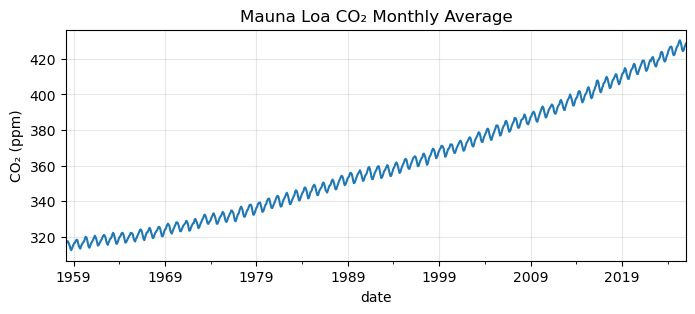

In [67]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"
df = pd.read_csv(
    url,
    comment='#',    # skip NOAA comment lines
    header=None,
    sep=r"\s+",
)

df.drop([4, 5, 6, 7], axis=1, inplace=True)
df.columns=["year", "month", "full_date", "average"]

df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
df = df.set_index("date")
df.dropna(inplace=True)

df["average"].plot(figsize=(8,3))
plt.ylabel("CO₂ (ppm)")
plt.title("Mauna Loa CO₂ Monthly Average")
plt.grid(True, alpha=0.3)
plt.show()

In [66]:
df.head()

,year,month,full_date,average
date,,,,
1958-03-01,1958,3,1958.2027,315.71
1958-04-01,1958,4,1958.2877,317.45
1958-05-01,1958,5,1958.3699,317.51
1958-06-01,1958,6,1958.4548,317.27
1958-07-01,1958,7,1958.5370,315.87


In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [82]:
def decompose_timeseries(df, model, X, y_col="average", plot=True):
    """
    Fits model, extracts trend, removes it,
    computes seasonal component (monthly),
    and optionally plots results.
    """

    model.fit(X, df[y_col])
    df["trend"] = model.predict(X)
    df["no_trend"] = df[y_col] - df["trend"]

    seasonal_cycle = df["no_trend"].groupby(df.index.month).mean()
    df["season"] = df.index.month.map(seasonal_cycle)

    if plot:
        fig, axes = plt.subplots(
        2, 1, 
        figsize=(10, 7), 
        sharex=True)
        axes[0].plot(df.index, df[y_col], label="Observed")
        axes[0].plot(df.index, df["trend"], label="Trend")
        axes[0].set_title("Trend Fit")
        axes[0].set_ylabel("Value")
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        axes[1].plot(df.index, df["no_trend"], label="Detrended")
        axes[1].plot(df.index, df["season"], label="Seasonal")
        axes[1].set_title("Seasonal Component")
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return df, seasonal_cycle

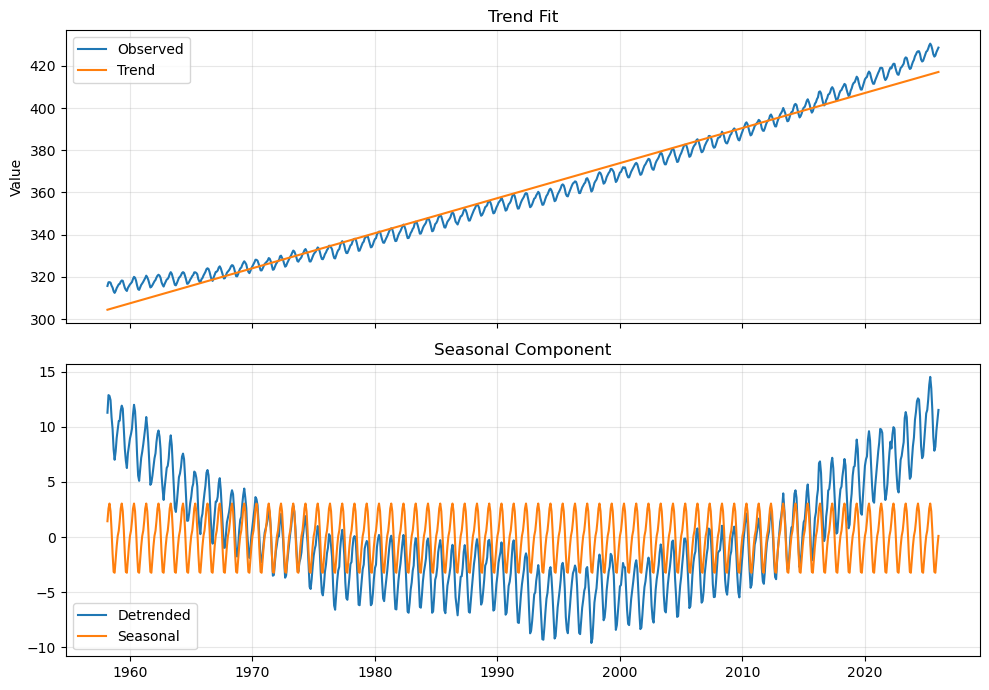

In [83]:
X = df[["full_date"]]
Y = df["average"]

model = LinearRegression()
df, seasonal = decompose_timeseries(df, model, X)


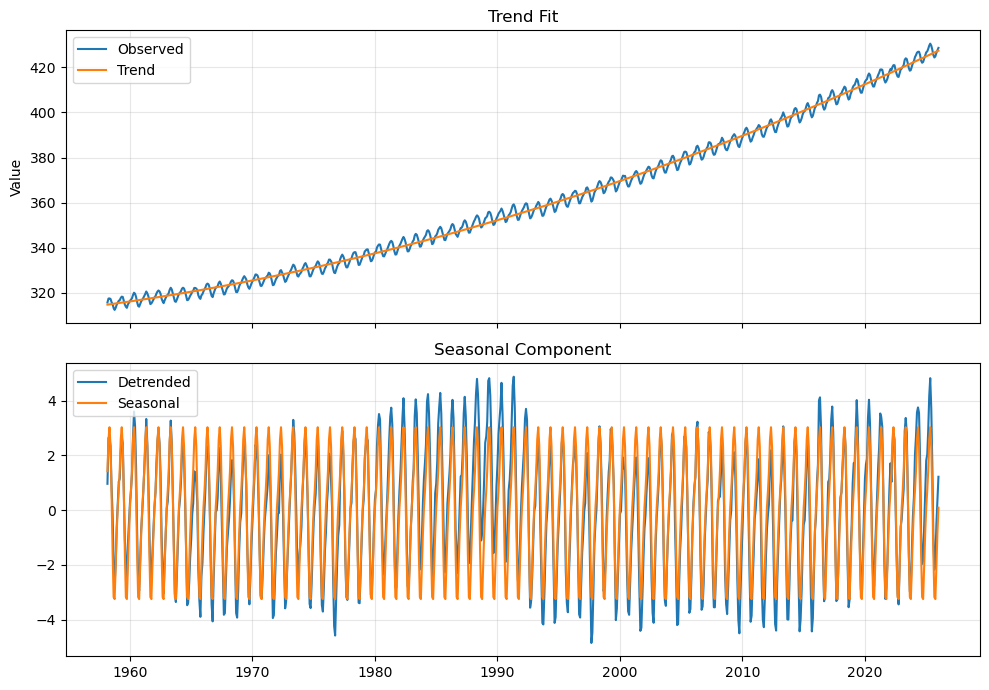

In [84]:
poly = PolynomialFeatures(2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
df, seasonal = decompose_timeseries(df, model, X_poly)

In [107]:
import statsmodels.api as sm

In [113]:
t = np.arange(len(df))
tau = 12
poly = PolynomialFeatures(degree=2, include_bias=True)
X_trend = poly.fit_transform(t.reshape(-1, 1))

trend_model = LinearRegression()
trend_model.fit(X_trend, df["average"])

df["trend"] = trend_model.predict(X_trend)
df["detrended"] = df["average"] - df["trend"]

X_season = np.column_stack([
    np.sin(2*np.pi*t/12),
    np.cos(2*np.pi*t/12),
    np.sin(2*np.pi*t/60)
    #,np.cos(2*np.pi*t/60)
])

## The tau 60 is completely add hoc and based only on the infromation I have seen after fitting

season_model = sm.OLS(df["detrended"], X_season).fit()
print(season_model.summary())

df["season"] = season_model.predict(X_season)
df["residual"] = df["detrended"] - df["season"]

                                 OLS Regression Results                                
Dep. Variable:              detrended   R-squared (uncentered):                   0.804
Model:                            OLS   Adj. R-squared (uncentered):              0.803
Method:                 Least Squares   F-statistic:                              1108.
Date:                Wed, 04 Mar 2026   Prob (F-statistic):                   1.89e-286
Time:                        13:55:01   Log-Likelihood:                         -1148.6
No. Observations:                 815   AIC:                                      2303.
Df Residuals:                     812   BIC:                                      2317.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [115]:
a, b, alpha = season_model.params
print(f"a = {a:.4f}, b = {b:.4f}")
print(f"a_60 = {alpha:.4f}")

a = 1.6424, b = 2.3035
a_60 = 0.1365


In [116]:
amplitude = np.sqrt(a**2 + b**2)
print(f"Seasonal amplitude ≈ {amplitude:.3f} ppm")

Seasonal amplitude ≈ 2.829 ppm


In [117]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season_name"] = df.index.month.map(month_to_season)

season_colors = {
    "Winter": "blue",
    "Spring": "green",
    "Summer": "red",
    "Fall": "orange"
}

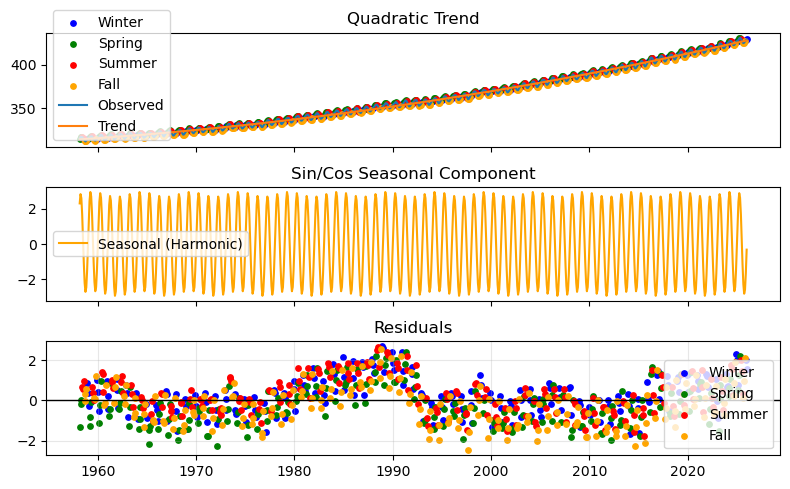

In [118]:
fig, axes = plt.subplots(3, 1, figsize=(8,5), sharex=True)

for s in season_colors:
    mask = df["season_name"] == s
    axes[0].scatter(df.index[mask], df["average"][mask],
                    color=season_colors[s], label=s, s=15)

axes[0].plot(df.index, df["average"], label="Observed")
axes[0].plot(df.index, df["trend"], label="Trend")
axes[0].legend()
axes[0].set_title("Quadratic Trend")

axes[1].plot(df.index, df["season"], label="Seasonal (Harmonic)", color="orange")
axes[1].legend()
axes[1].set_title("Sin/Cos Seasonal Component")

for s in season_colors:
    mask = df["season_name"] == s
    axes[2].scatter(df.index[mask], df["residual"][mask],
                    color=season_colors[s], s=15, label=s)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Residuals")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

There seem to be some separtion of the residuals depending on seasons. Not related to the course but we do a quick analysis. Probably first need to eliminate a extra peridcity in the residuals!!!

In [126]:
from statsmodels.tsa.seasonal import STL
# Fit a non parametric LOESS smoother

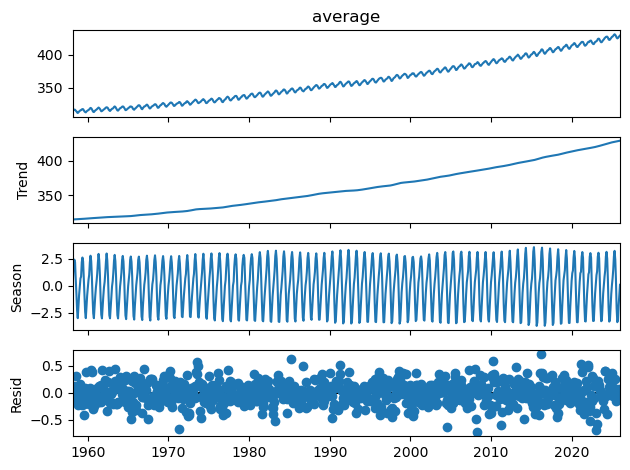

In [123]:
stl = STL(df["average"], period=12)
result = stl.fit()

df["trend"] = result.trend
df["season"] = result.seasonal
df["residual"] = result.resid

fig = result.plot()